In [4]:
import networkx as nx
import numpy as np
from Main_Code import CreateGraphs, BaseLine, SubQuad
import time
import matplotlib.pyplot as plt

Benchmarking Runtime and Accuracy...
Testing N = 100...
161.08182106909143
159.8299999999999
Testing N = 300...
40.069891900943254
52.39666666666669
Testing N = 500...
28.438738010421716
33.29399999999994
Testing N = 1000...
15.096528337700688
16.73999999999997
Testing N = 1500...
11.097935878075504
11.202666666666648
Testing N = 2000...
8.834739350434761
8.931999999999986
Testing N = 2500...
7.060871159441612
7.038799999999844


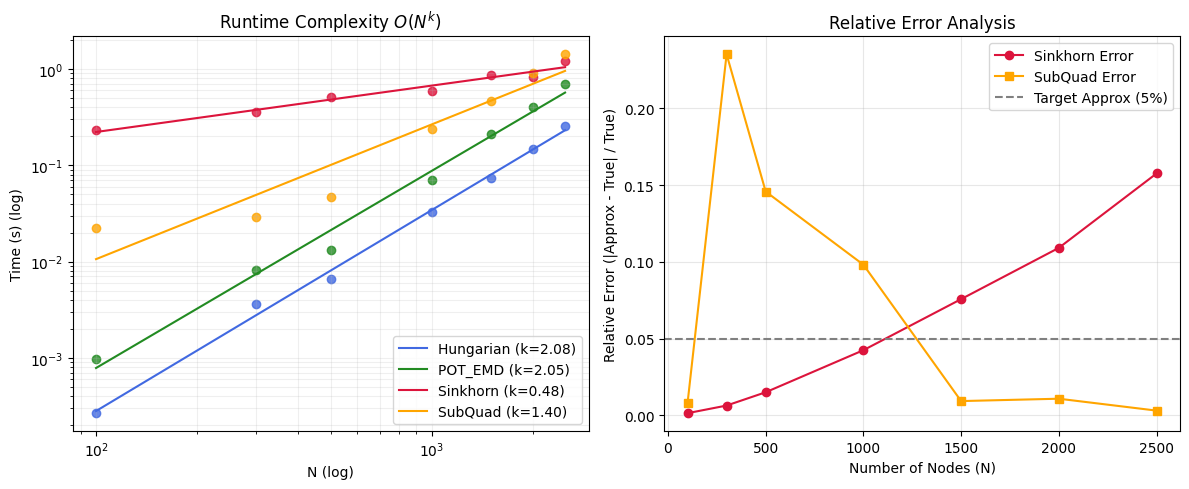


Final Results for N=2500:
SubQuad Error: 0.0031
Sinkhorn Error: 0.1576


In [5]:
def main():
    #n_values = [100, 300, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 5000, 7500, 10_000, 15_000]
    n_values = [100, 300, 500, 1000, 1500, 2000, 2500]
    # We track both runtime and the computed cost to evaluate accuracy
    results = {'Hungarian': [], 'POT_EMD': [], 'Sinkhorn': [], 'SubQuad': []}
    accuracy = {'Sinkhorn': [], 'SubQuad': []}
    print("Benchmarking Runtime and Accuracy...")
    for n in n_values:
        print(f"Testing N = {n}...")
        C = CreateGraphs.generate_dense_ot_data(n)
        
        t0 = time.perf_counter()
        true_cost = BaseLine.solve_pot_emd(C) 
        results['POT_EMD'].append(time.perf_counter() - t0)
        
        t0 = time.perf_counter()
        BaseLine.solve_Hungarian(C)
        results['Hungarian'].append(time.perf_counter() - t0)
        
        t0 = time.perf_counter()
        sink_cost = BaseLine.solve_pot_sinkhorn(C, reg=0.0003)
        results['Sinkhorn'].append(time.perf_counter() - t0)
        accuracy['Sinkhorn'].append(abs((sink_cost) - true_cost) / true_cost)
        
        t0 = time.perf_counter()
        sub_quad_cost = SubQuad.solve_Sub_Quad(C, 30, 0.05)
        print(sub_quad_cost[0]/n)
        print(true_cost)
        results['SubQuad'].append(time.perf_counter() - t0)
        accuracy['SubQuad'].append(abs((sub_quad_cost[0]/n) - true_cost) / true_cost)
        
        
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    colors = {'Hungarian': 'royalblue', 'POT_EMD': 'forestgreen', 'Sinkhorn': 'crimson', 'SubQuad': 'orange'}
    for method, times in results.items():
        log_n = np.log(n_values)
        log_t = np.log(times)
        k, log_c = np.polyfit(log_n, log_t, 1)
        plt.scatter(n_values, times, color=colors[method], alpha=0.8)
        fit_line = np.exp(log_c) * (np.array(n_values)**k)
        plt.plot(n_values, fit_line, color=colors[method], 
                 label=f'{method} (k={k:.2f})')
    plt.xscale('log')
    plt.yscale('log')
    plt.title('Runtime Complexity $O(N^k)$')
    plt.xlabel('N (log)')
    plt.ylabel('Time (s) (log)')
    plt.legend()
    plt.grid(True, which="both", alpha=0.2)
    plt.subplot(1, 2, 2)
    plt.plot(n_values, accuracy['Sinkhorn'], marker='o', color='crimson', label='Sinkhorn Error')
    plt.plot(n_values, accuracy['SubQuad'], marker='s', color='orange', label='SubQuad Error')
    
    plt.title('Relative Error Analysis')
    plt.xlabel('Number of Nodes (N)')
    plt.ylabel('Relative Error (|Approx - True| / True)')
    plt.axhline(y=0.05, color='gray', linestyle='--', label='Target Approx (5%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"\nFinal Results for N={n_values[-1]}:")
    print(f"SubQuad Error: {accuracy['SubQuad'][-1]:.4f}")
    print(f"Sinkhorn Error: {accuracy['Sinkhorn'][-1]:.4f}")
main()

         N |  Hungarian |    POT_EMD |   Sinkhorn |    SubQuad
-----------------------------------------------------------------
44.497334144052886
42.63000000000003
52.78223060384026
46.75750000000003
33.42988152659832
47.87222222222211
30.809651923841773
47.78639999999987


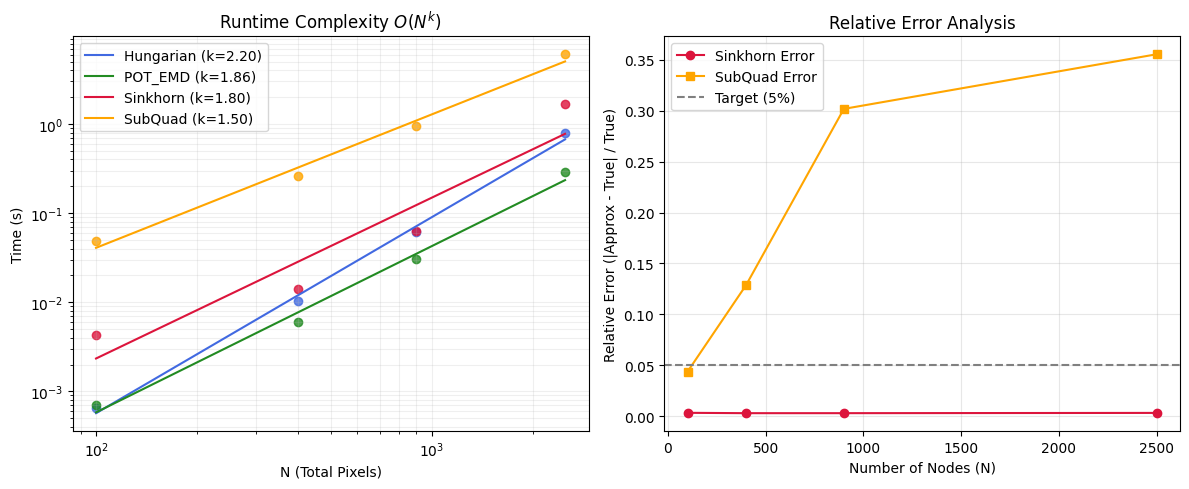


Final Results for N=2500:
SubQuad Error: 0.3553
Sinkhorn Error: 0.0034


In [15]:
import numpy as np
import time
from torchvision import datasets, transforms

sizes = [10, 20, 30,50] #N x N image
n_values = [s * s for s in sizes]

results2 = {name: [] for name in ['Hungarian', 'POT_EMD', 'Sinkhorn', 'SubQuad']}
accuracy2 = {'Sinkhorn': [], 'SubQuad': []}

#Turn image into grayscale
transform_base = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

# Load dataset
dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_base)

print(f"{'N':>10} | {'Hungarian':>10} | {'POT_EMD':>10} | {'Sinkhorn':>10} | {'SubQuad':>10}")
print("-" * 65)

for s in sizes:
    N = s * s
    
    # 1. Prepare images: Resize to the target N
    t = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((s, s)),
        transforms.ToTensor()
    ])
    
    img1 = t(dataset[42][0]).numpy().flatten() * 255 #laoding fixed images
    img2 = t(dataset[1337][0]).numpy().flatten() * 255

    # Cost Matrix
    C = np.abs(img1[:, np.newaxis] - img2[np.newaxis, :])
    
    # Define cost range for SubQuad
    cost_range = 255
    
    # POT_EMD
    t0 = time.perf_counter()
    true_cost = BaseLine.solve_pot_emd(C) 
    results2['POT_EMD'].append(time.perf_counter() - t0)
    
    # Hungarian
    t0 = time.perf_counter()
    BaseLine.solve_Hungarian(C)
    results2['Hungarian'].append(time.perf_counter() - t0)
    
    # Sinkhorn
    t0 = time.perf_counter()
    sink_cost = BaseLine.solve_pot_sinkhorn(C, reg=0.01)
    sink_cost = sink_cost
    results2['Sinkhorn'].append(time.perf_counter() - t0)
    accuracy2['Sinkhorn'].append(abs(sink_cost - true_cost) / (true_cost))
    
    # SubQuad
    t0 = time.perf_counter()
    sub_quad_res = SubQuad.solve_Sub_Quad(C, 500, 0.05, cost_range)
    sub_quad_cost = sub_quad_res[0]
    #sub_quad_cost = abs(sub_quad_cost)
    print(sub_quad_cost/(s * 2))
    print(true_cost) 
    results2['SubQuad'].append(time.perf_counter() - t0)
    accuracy2['SubQuad'].append(abs((sub_quad_cost / (s * 2)) - true_cost) / (true_cost))
    
plt.figure(figsize=(12, 5))

# Plot 1: Runtime Complexity (Log-Log)
plt.subplot(1, 2, 1)
colors = {'Hungarian': 'royalblue', 'POT_EMD': 'forestgreen', 'Sinkhorn': 'crimson', 'SubQuad': 'orange'}

for method, times in results2.items():
    log_n = np.log(n_values)
    log_t = np.log(times)
    k, log_c = np.polyfit(log_n, log_t, 1)
    
    plt.scatter(n_values, times, color=colors[method], alpha=0.8)
    fit_line = np.exp(log_c) * (np.array(n_values)**k)
    plt.plot(n_values, fit_line, color=colors[method], 
                label=f'{method} (k={k:.2f})')

plt.xscale('log')
plt.yscale('log')
plt.title('Runtime Complexity $O(N^k)$')
plt.xlabel('N (Total Pixels)')
plt.ylabel('Time (s)')
plt.legend()
plt.grid(True, which="both", alpha=0.2)

# Plot 2: Accuracy Analysis
plt.subplot(1, 2, 2)
plt.plot(n_values, accuracy2['Sinkhorn'], marker='o', color='crimson', label='Sinkhorn Error')
plt.plot(n_values, accuracy2['SubQuad'], marker='s', color='orange', label='SubQuad Error')

plt.title('Relative Error Analysis')
plt.xlabel('Number of Nodes (N)')
plt.ylabel('Relative Error (|Approx - True| / True)')
plt.axhline(y=0.05, color='gray', linestyle='--', label='Target (5%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Results for N={n_values[-1]}:")
print(f"SubQuad Error: {accuracy2['SubQuad'][-1]:.4f}")
print(f"Sinkhorn Error: {accuracy2['Sinkhorn'][-1]:.4f}")